In [1]:
%config InlineBackend.figure_format = 'svg' # Make the image looks nice

In [2]:
# importing Qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

# import basic plot tools
from qiskit.visualization import plot_histogram

Consider 4 elements in which our goal is to find out the index of the element which meets certain requirements, such as the value is equal to 2. The quantum state |01> represents the index.

### Initialization

In [ ]:
def initialization(circuit):
    # Initialization
    n = circuit.num_qubits
    # For input qubits
    for qubit in range(n - 1):
        circuit.h(qubit)
    # For the ancilla qubit - initialize to minus state
    circuit.x(n - 1)        
    circuit.h(n - 1)
    circuit.barrier()
    return circuit

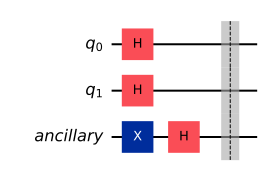

In [4]:
n = 2
qr = QuantumRegister(n, "q")
anc = QuantumRegister(1, "ancillary")
initialization_circuit = QuantumCircuit(qr, anc)

initialization(initialization_circuit)
initialization_circuit.draw("mpl")

### Oracle
It marks the target state by applying a phase shift, typically flipping the sign of the amplitude associated with that state. This phase flip is achieved by applying a negative sign to the amplitude of the target state via phase kickback. 

In [5]:
def oracle(circuit):
    circuit.x(1)
    circuit.ccx(0, 1, 2)
    circuit.x(1)
    circuit.barrier()

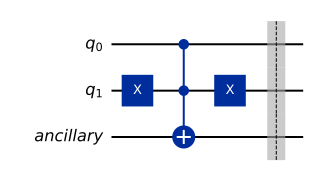

In [7]:
n = 2
qr = QuantumRegister(n, "q")
anc = QuantumRegister(1, "ancillary")
oracle_circuit = QuantumCircuit(qr, anc)

oracle(oracle_circuit)
oracle_circuit.draw("mpl")

### Diffusion operator
It performs the amplitude amplification. Basically, it inverts about the average amplitude.

D=2∣ψ⟩⟨ψ∣−I, where D is the diffusion operator, I is the identity matrix and ∣ψ⟩ is the equal superposition state. The combination of oracle and diffusion operator is applied approximately squareroot of N times to achieve maximum probability for measuring the marked state.

In [8]:
def diffusion(circuit):
    input_qubits = circuit.num_qubits - 1
    circuit.h(range(0, input_qubits))
    circuit.x(range(0, input_qubits))
    circuit.h(input_qubits - 1)
    circuit.mcx([i for i in range(0, input_qubits - 1)], input_qubits - 1)
    circuit.h(input_qubits - 1)
    circuit.x(range(0, input_qubits))
    circuit.h(range(0, input_qubits))
    circuit.barrier()

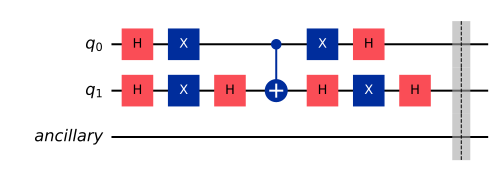

In [13]:
n = 2
qr = QuantumRegister(n, "q")
anc = QuantumRegister(1, "ancillary")
diffusion_circuit = QuantumCircuit(qr, anc)

diffusion(diffusion_circuit)
diffusion_circuit.draw("mpl")

## A 2-qubit example

In [19]:
n = 2
qr = QuantumRegister(n, "q")
anc = QuantumRegister(1, "ancillary")
meas = ClassicalRegister(3, "meas")
grover_circuit = QuantumCircuit(qr, anc, meas)

In [20]:
# the number of iterations
num_iterations = 1

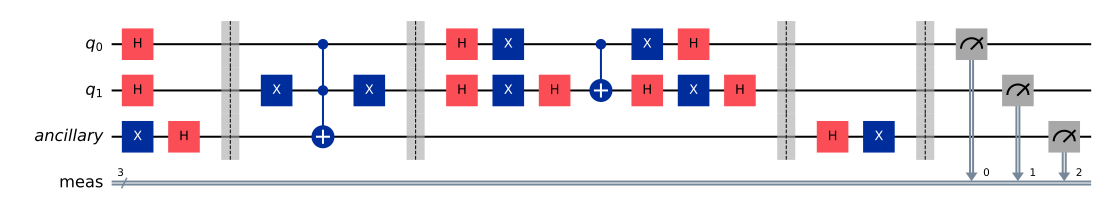

In [21]:
# Let's do Grover search
initialization(grover_circuit)

for i in range(0, num_iterations):
    oracle(grover_circuit)
    diffusion(grover_circuit)
    
# Clear the ancilla bit
grover_circuit.h(n)
grover_circuit.x(n)
grover_circuit.measure_all(add_bits=False)

grover_circuit.draw("mpl", idle_wires= False)


## Implement in Simulator

In [22]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Define backend
backend = AerSimulator()

# Transpile to backend
pm = generate_preset_pass_manager(backend=backend, optimization_level= 1)
isa_qc = pm.run(grover_circuit)

# Run the job
sampler = Sampler(mode = backend)
job = sampler.run([isa_qc])
result = job.result()

{'001': 1024}


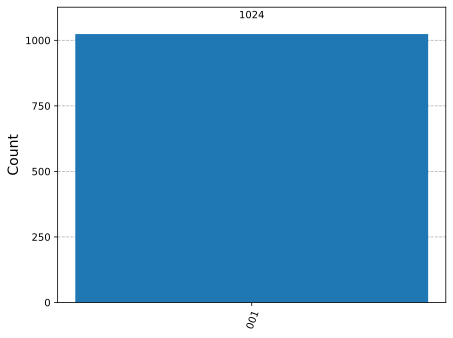

In [23]:
# Print the results
counts = result[0].data.meas.get_counts()
print(counts)

# Plot the counts in a histogram
plot_histogram(counts)

## Experiment with real devices

In [27]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(channel="ibm_quantum_platform", 
                                            token="EFDQKmCm07x_vvfa1EVu_Ng2UkfhuqYK7xJWYtBDGYqU", 
                                            overwrite=True,
                                            set_as_default= True,)
service = QiskitRuntimeService(channel="ibm_quantum_platform")
real_backend = service.backend("ibm_fez")

qiskit_runtime_service.__init__:WARNING:2026-09-22 16:02:24,469: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-22 16:02:24,470: Using instance: open-instance, plan: open


In [28]:
service.least_busy(simulator=False, operational = True)

qiskit_runtime_service.backends:WARNING:2026-09-22 16:10:54,443: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-22 16:10:58,288: Using instance: open-instance, plan: open


<IBMBackend('ibm_marrakesh')>

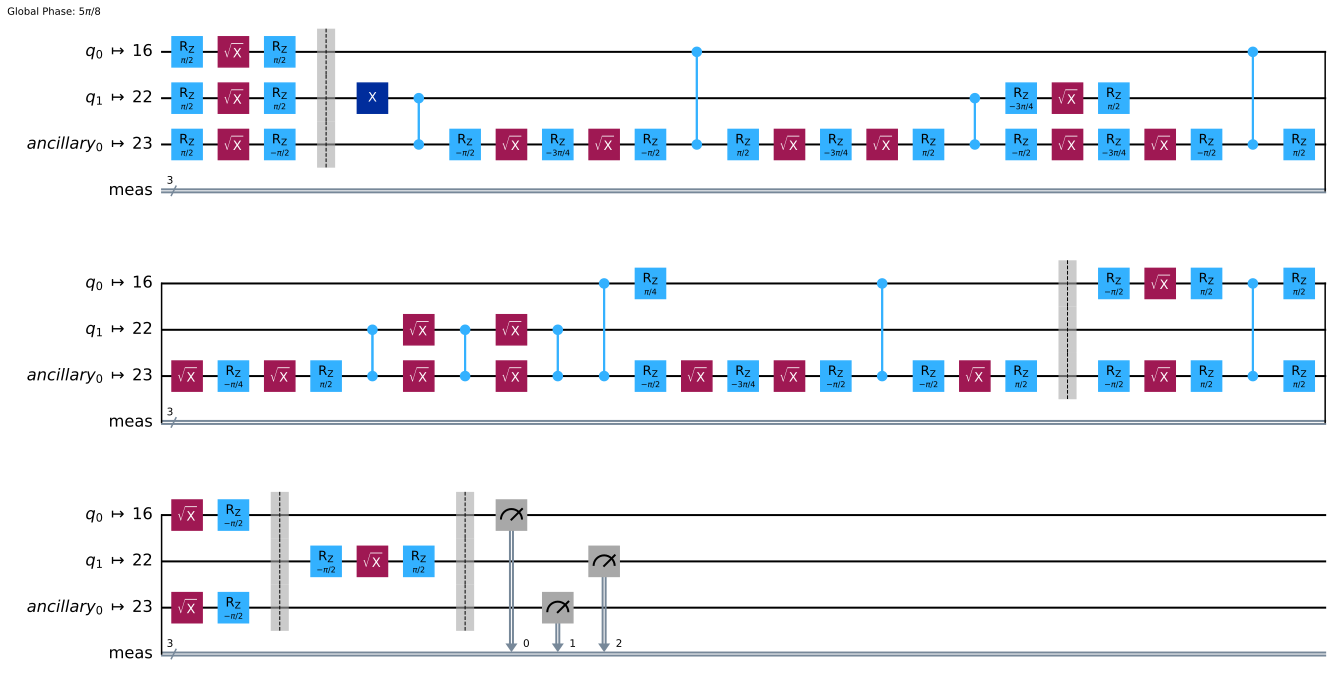

In [35]:
# Transpile the circuit into basis gates executable on the hardware
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=real_backend, optimization_level= 1)
target_circuit = pm.run(grover_circuit)

target_circuit.draw("mpl", idle_wires= False)

qiskit_runtime_service.backends:WARNING:2026-09-22 16:16:53,529: Using instance: open-instance, plan: open


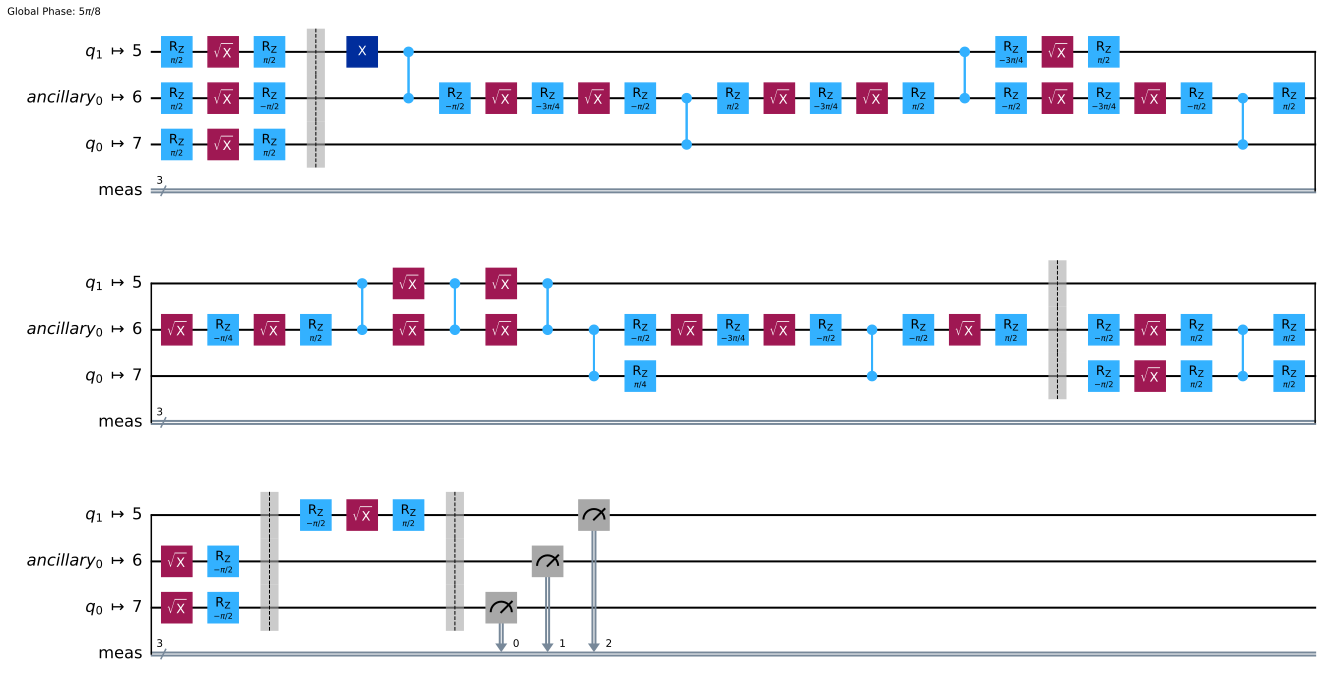

In [40]:
real_backend1 = service.backend("ibm_marrakesh")

pm = generate_preset_pass_manager(backend=real_backend1, optimization_level= 1)
target_circuit = pm.run(grover_circuit)

target_circuit.draw("mpl", idle_wires= False)

In [41]:
sampler = Sampler(real_backend)
job_real = sampler.run([target_circuit])
job_id = job_real.job_id()
print("job id:", job_id)

job id: dap5pvn8gn2s739ool50


In [42]:
job_real.status()

'DONE'

In [43]:
result_real = job_real.result()
print(result_real[0].data.meas.get_counts())

{'001': 3233, '110': 42, '000': 216, '101': 109, '011': 246, '100': 117, '010': 82, '111': 51}


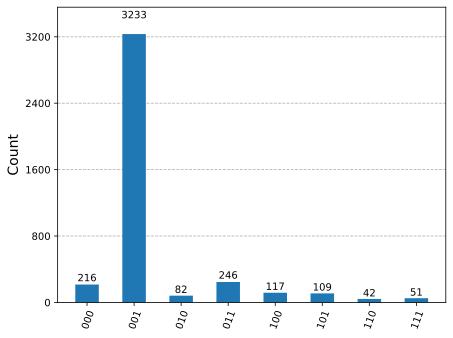

In [44]:
plot_histogram(result_real[0].data.meas.get_counts())

# A 3-qubit Grover Search

In [53]:
n = 3
qr = QuantumRegister(n, "q")
anc = QuantumRegister(1, "ancilla")
grover_circuit = QuantumCircuit(qr, anc)

In [46]:
# number of iterations
num_iterations = 2

In [ ]:
# This time |111> is the marked state
def oracle(circuit):
    circuit.mcx([0, 1, 2], 3)
    circuit.barrier()

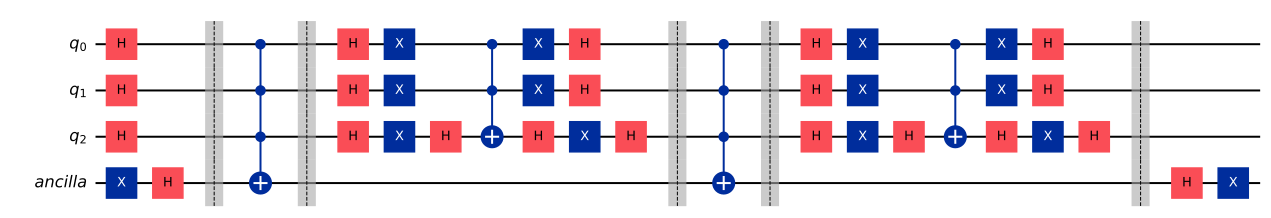

In [54]:
# Grover search
initialization(grover_circuit)

for i in range(0, num_iterations):
    oracle(grover_circuit)
    diffusion(grover_circuit)
    
# Clear the ancilla qubit
grover_circuit.h(n)
grover_circuit.x(n)

grover_circuit.draw("mpl", idle_wires = False)

{'0111': 932, '0101': 14, '0000': 5, '0011': 16, '0001': 5, '0100': 12, '0110': 12, '0010': 4}


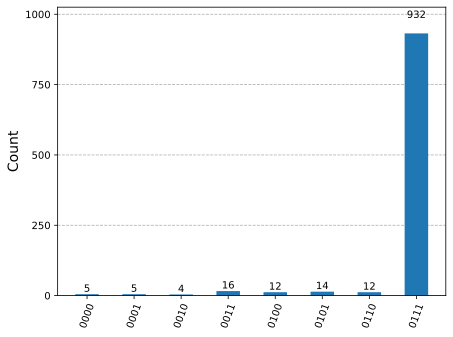

In [57]:
grover_circuit.measure_all()

# Define the backend
backend = AerSimulator()

# Transpile to backend
pm = generate_preset_pass_manager(backend=backend, optimization_level= 1)
isa_qc = pm.run(grover_circuit)

# Run the job
sampler = Sampler(backend)
job = sampler.run([isa_qc], shots = 1000)
result = job.result()

# Print the results
counts = result[0].data.meas.get_counts()
print(counts)
plot_histogram(counts)

In [73]:
# Iterate more 
n = 3
qr = QuantumRegister(n, "q")
anc = QuantumRegister(1, "ancillary")
grover_circuit_3 = QuantumCircuit(qr, anc)

In [74]:
# number of iterations
num_iterations = 3

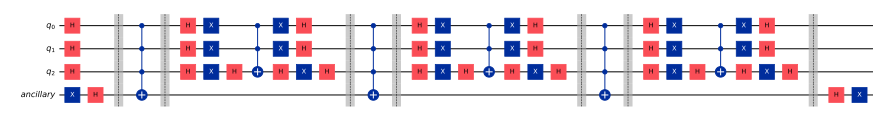

In [75]:
# Grover search
initialization(grover_circuit_3)

for i in range(0, num_iterations):
    oracle(grover_circuit_3)
    diffusion(grover_circuit_3)

# clear the ancilla 
grover_circuit_3.h(n)
grover_circuit_3.x(n)

grover_circuit_3.draw("mpl", idle_wires= False, fold = -1, scale = 0.5)

{'0111': 322, '0001': 85, '0110': 90, '0011': 113, '0000': 97, '0010': 106, '0100': 81, '0101': 106}


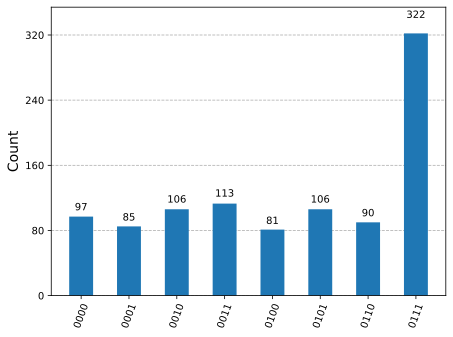

In [79]:
grover_circuit_3.measure_all()

# Define backend
backend = AerSimulator()

# Transpile to backend
pm = generate_preset_pass_manager(backend=backend, optimization_level= 1)
isa_qc = pm.run(grover_circuit_3)

# Run the job
sampler = Sampler(backend)
job = sampler.run([isa_qc], shots = 1000)
result = job.result()[0].data.meas.get_counts()
print(result)

plot_histogram(result)

# Iterations = 4

In [80]:
# Iterate more 
n = 3
qr = QuantumRegister(n, "q")
anc = QuantumRegister(1, "ancillary")
grover_circuit = QuantumCircuit(qr, anc)

In [81]:
num_iterations = 4


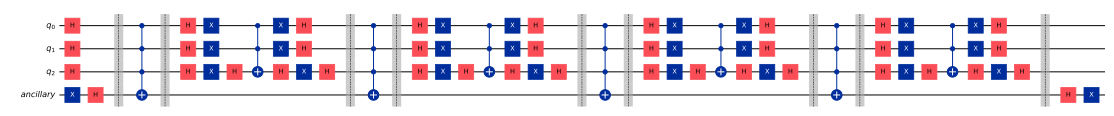

In [82]:
# Grover search
initialization(grover_circuit)

for i in range(0, num_iterations):
    oracle(grover_circuit)
    diffusion(grover_circuit)

# clear the ancilla 
grover_circuit.h(n)
grover_circuit.x(n)

grover_circuit.draw("mpl", idle_wires= False, fold = -1, scale = 0.5)

{'0101': 145, '0000': 132, '0100': 150, '0001': 137, '0011': 117, '0110': 150, '0010': 158, '0111': 10}


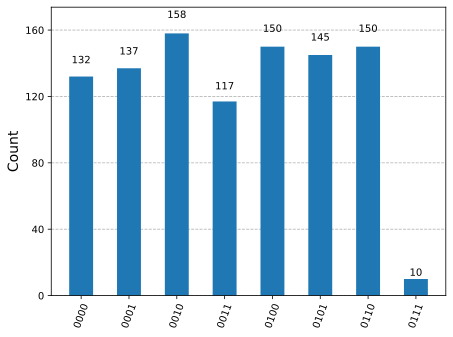

In [83]:
grover_circuit.measure_all()

# Define backend
backend = AerSimulator()

# Transpile to backend
pm = generate_preset_pass_manager(backend=backend, optimization_level= 1)
isa_qc = pm.run(grover_circuit)

# Run the job
sampler = Sampler(backend)
job = sampler.run([isa_qc], shots = 999)
result = job.result()[0].data.meas.get_counts()
print(result)

plot_histogram(result)